In [1]:
import os

import torch
from diffusers import DDIMScheduler, AutoencoderKL
from PIL import Image
from safetensors.torch import load_model

from powerpaint.pipelines import StableDiffusionInpaintIndomainPipeline
from powerpaint.utils.utils import TokenizerWrapper, add_tokens
from ip_adapter import IPAdapter

/mnt/disk1/aiotlab/envs/powerpaint/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
base_model_path = '/mnt/disk2/hachi/checkpoints/stable-diffusion-inpainting'
ppt1_checkpoint = '/mnt/disk2/hachi/checkpoints/ppt-v1'
image_encoder_path = "/mnt/disk2/hachi/checkpoints/IP-Adapter/models/image_encoder"
ip_ckpt = "/mnt/disk2/hachi/checkpoints/IP-Adapter/models/ip-adapter_sd15.bin"
device = "cuda:1"

In [3]:
### Load base model
pipe = StableDiffusionInpaintIndomainPipeline.from_pretrained(
        base_model_path,
        torch_dtype=torch.float16,
        local_files_only=True
)
pipe.tokenizer = TokenizerWrapper(
        from_pretrained=base_model_path,
        subfolder='tokenizer',
        torch_dtype=torch.float16,
        local_files_only=True
)

# add pretrained learned task tokens into the tokenizer
add_tokens(
    tokenizer=pipe.tokenizer,
    text_encoder=pipe.text_encoder,
    placeholder_tokens=["P_ctxt", "P_shape", "P_obj"],
    initialize_tokens=["a", "a", "a"],
    num_vectors_per_token=10,
)
# load ppt1 checkpoint
load_model(pipe.unet, os.path.join(ppt1_checkpoint, "unet/unet.safetensors"), strict=False)
load_model(pipe.text_encoder, os.path.join(ppt1_checkpoint, "text_encoder/text_encoder.safetensors"),strict=False )


Loading pipeline components...: 100%|██████████| 7/7 [00:26<00:00,  3.75s/it]

01/06 10:03:20 - mmengine - INFO - Successfully add external embeddings: P_ctxt, P_shape, P_obj.
01/06 10:03:20 - mmengine - INFO - Successfully add trainable external embeddings: P_ctxt, P_shape, P_obj


(set(), set())

In [40]:
def image_grid(imgs, rows, cols):
    assert len(imgs) == rows*cols

    w, h = imgs[0].size
    print(w, h)
    grid = Image.new('RGB', size=(cols*w, rows*h))
    grid_w, grid_h = grid.size
    
    for i, img in enumerate(imgs):
        grid.paste(img, box=(i%cols*w, i//cols*h))
    return grid

def expand_bbox(bbox, image_size, scale=1.3):
    """
    bbox: [x_min, y_min, x_max, y_max]
    image_size: (width, height)
    scale: hệ số mở rộng bbox
    """
    x_min, y_min, x_max, y_max = bbox
    img_w, img_h = image_size

    # Kích thước bbox gốc
    w = x_max - x_min
    h = y_max - y_min

    # Tâm bbox
    cx = (x_min + x_max) / 2
    cy = (y_min + y_max) / 2

    # Kích thước mới
    new_w = w * scale
    new_h = h * scale

    # Tính bbox mới
    new_x_min = int(cx - new_w / 2)
    new_y_min = int(cy - new_h / 2)
    new_x_max = int(cx + new_w / 2)
    new_y_max = int(cy + new_h / 2)

    # Clamp vào biên ảnh
    new_x_min = max(0, new_x_min)
    new_y_min = max(0, new_y_min)
    new_x_max = min(img_w, new_x_max)
    new_y_max = min(img_h, new_y_max)

    return [new_x_min, new_y_min, new_x_max, new_y_max]

def expand_bbox_square(bbox, image_size, scale=1.3):
    """
    bbox: [x_min, y_min, x_max, y_max]
    image_size: (width, height)
    scale: hệ số mở rộng bbox
    """
    x_min, y_min, x_max, y_max = bbox
    img_w, img_h = image_size

    # Kích thước bbox gốc
    w = x_max - x_min
    h = y_max - y_min

    # Tâm bbox
    cx = (x_min + x_max) / 2.0
    cy = (y_min + y_max) / 2.0

    # Cạnh bbox vuông sau khi scale
    side = max(w, h) * scale
    half_side = side / 2.0

    # Bbox vuông mới (chưa clamp)
    new_x_min = cx - half_side
    new_y_min = cy - half_side
    new_x_max = cx + half_side
    new_y_max = cy + half_side

    # Clamp vào biên ảnh
    new_x_min = max(0, new_x_min)
    new_y_min = max(0, new_y_min)
    new_x_max = min(img_w, new_x_max)
    new_y_max = min(img_h, new_y_max)

    # Ép về int
    return [
        int(round(new_x_min)),
        int(round(new_y_min)),
        int(round(new_x_max)),
        int(round(new_y_max)),
    ]



In [96]:
path = '/mnt/disk1/aiotlab/hachi/PowerPaint/validation/val/573_b3'

img_path = os.path.join(path, 'ground_truth.png')
mask_path = os.path.join(path, 'mask.png')
json_path = os.path.join(path, 'anno.json')

import json
with open(json_path, 'r') as f:
    examplar = json.load(f)

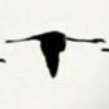

In [97]:
# read image prompt
bbox = examplar['examplar_bbox']
# bbox = [333,
#     302,
#     448,
#     417]
image = Image.open(img_path)
expanded_bbox = expand_bbox_square(
    bbox=bbox,
    image_size=image.size,
    scale=1.1   # bạn có thể thử 1.2 – 1.5
)

cropped_image = image.crop(expanded_bbox)
cropped_image

In [83]:
cropped_image.size

(161, 162)

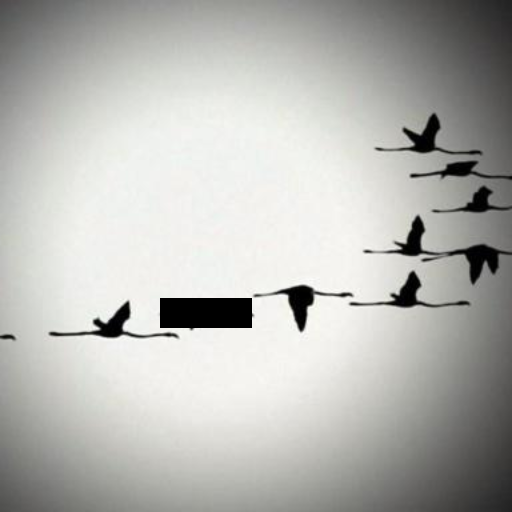

In [98]:
from PIL import Image
import numpy as np

image_tmp = Image.open(img_path).convert("RGB")
mask_tmp = Image.open(mask_path).convert("L")

# ĐẢO MASK
mask_tmp = Image.eval(mask_tmp, lambda x: 255 - x)

image_np = np.array(image_tmp)
mask_np = np.array(mask_tmp) / 255.0

masked_np = image_np * mask_np[..., None]
masked_img_tmp = Image.fromarray(masked_np.astype("uint8"))
masked_img_tmp


512 512


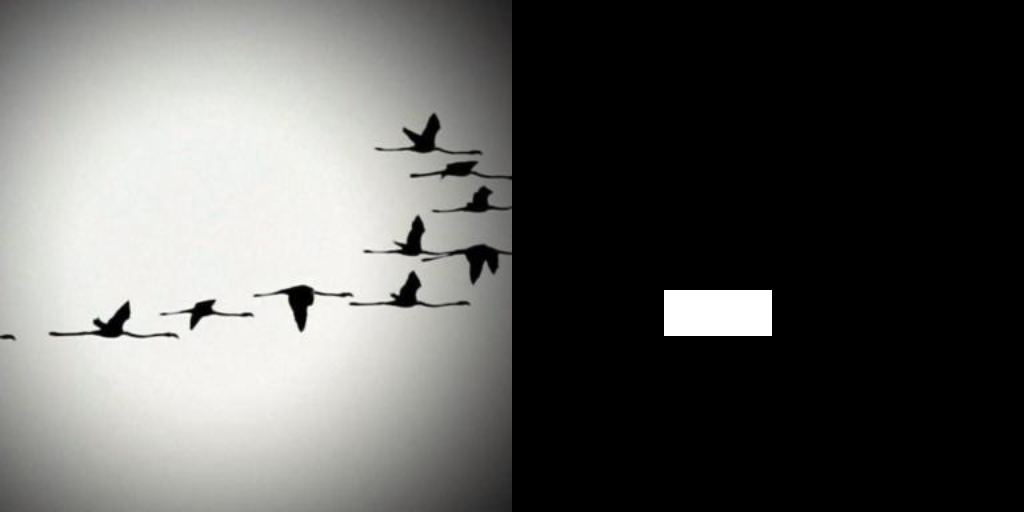

In [99]:
masked_image = Image.open(img_path)
mask = Image.open(mask_path)

import numpy as np
import cv2
from PIL import Image

def expand_mask_for_powerpaint(mask: Image.Image, expand_px=8):
    """
    mask: PIL Image (đen / trắng)
    expand_px: số pixel nới mask ra mỗi phía
    """
    mask_np = np.array(mask)

    # Đảm bảo mask 1 kênh
    if mask_np.ndim == 3:
        mask_np = mask_np[..., 0]

    # Nhị phân hóa
    mask_bin = (mask_np > 0).astype(np.uint8) * 255

    # Kernel giãn
    kernel = np.ones((expand_px * 2 + 1, expand_px * 2 + 1), np.uint8)

    expanded_mask = cv2.dilate(mask_bin, kernel, iterations=1)

    return Image.fromarray(expanded_mask)

mask = expand_mask_for_powerpaint(mask, expand_px=8)

image_grid([masked_image, mask], 1, 2)

In [8]:
# load ip-adapter
ip_model = IPAdapter(pipe, image_encoder_path, ip_ckpt, device)

100%|██████████| 35/35 [00:09<00:00,  3.57it/s]


512 512


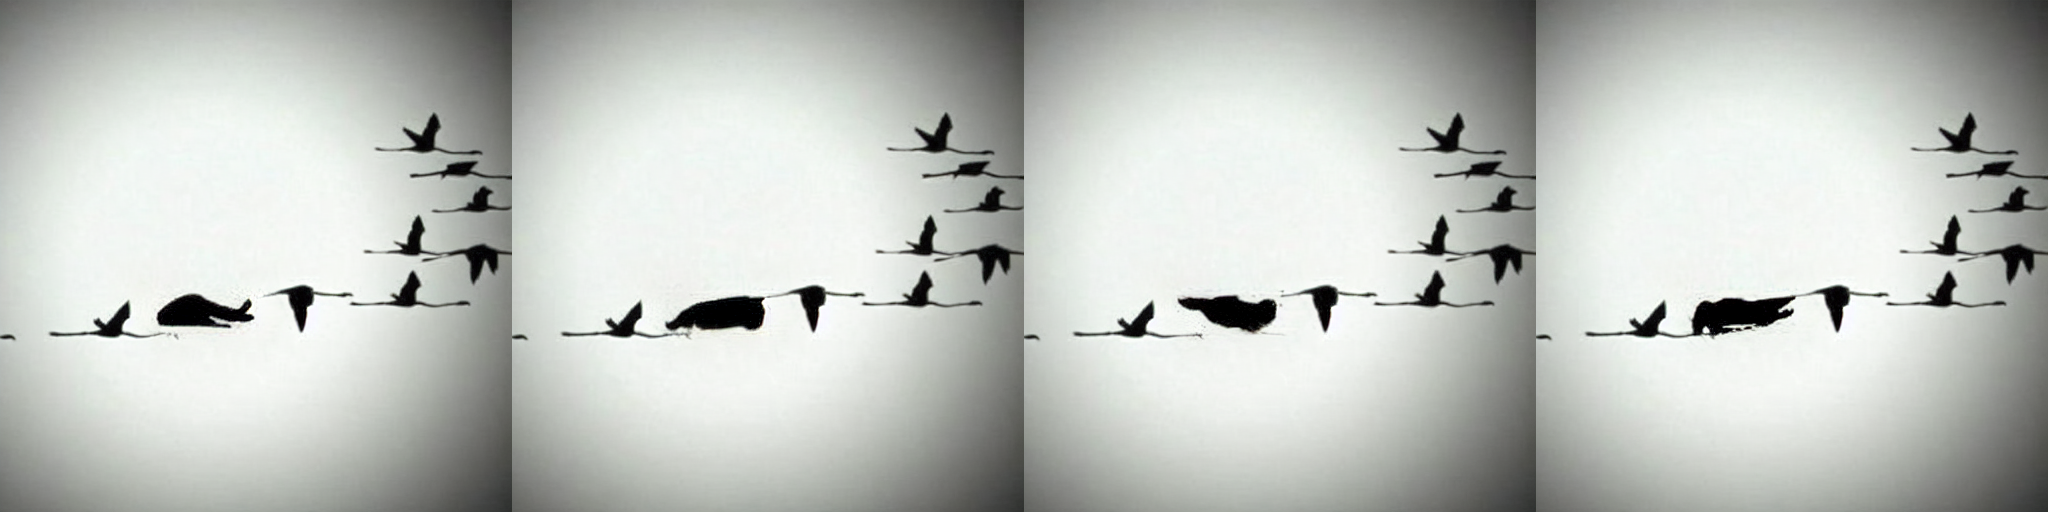

In [101]:
promptA = 'a flamingo P_ctxt'
promptB = 'a flamingo P_ctxt'
# generate
images = ip_model.generate(pil_image=cropped_image, num_samples=4, num_inference_steps=50,
                           seed=42, image=masked_img_tmp, mask=mask, strength=0.7, promptA=promptA, promptB=promptB)
grid = image_grid(images, 1, 4)
grid

512 512


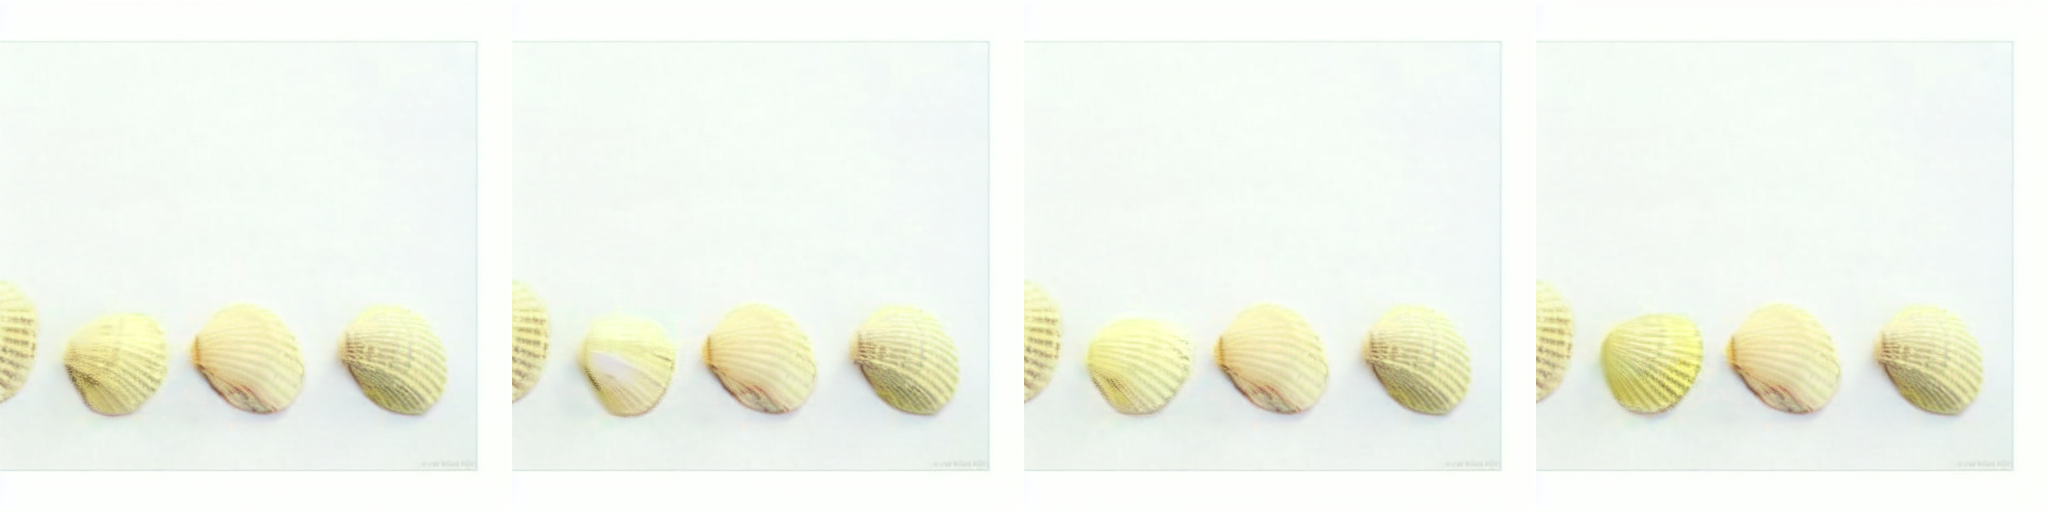

In [13]:
grid = image_grid(images, 1, 4)
grid